In [1]:
#IMPORT REQUIRED LIBRARIES
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb

In [2]:
#IMPORT DATASET AND  LOAD
#IMAGES WITH WHITE AND BLACK PIXELS
cifar10 = keras.datasets.cifar10

#SPLIT IN TRAINING AND TESTING DATA
(X_train_full, y_train_full),(X_test, y_test) = cifar10.load_data()

In [3]:
X_train_full.shape

(50000, 32, 32, 3)

In [4]:
X_test.shape

(10000, 32, 32, 3)

In [5]:
#BIGGER NUMBER< WHITER PIXEL
X_train_full[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

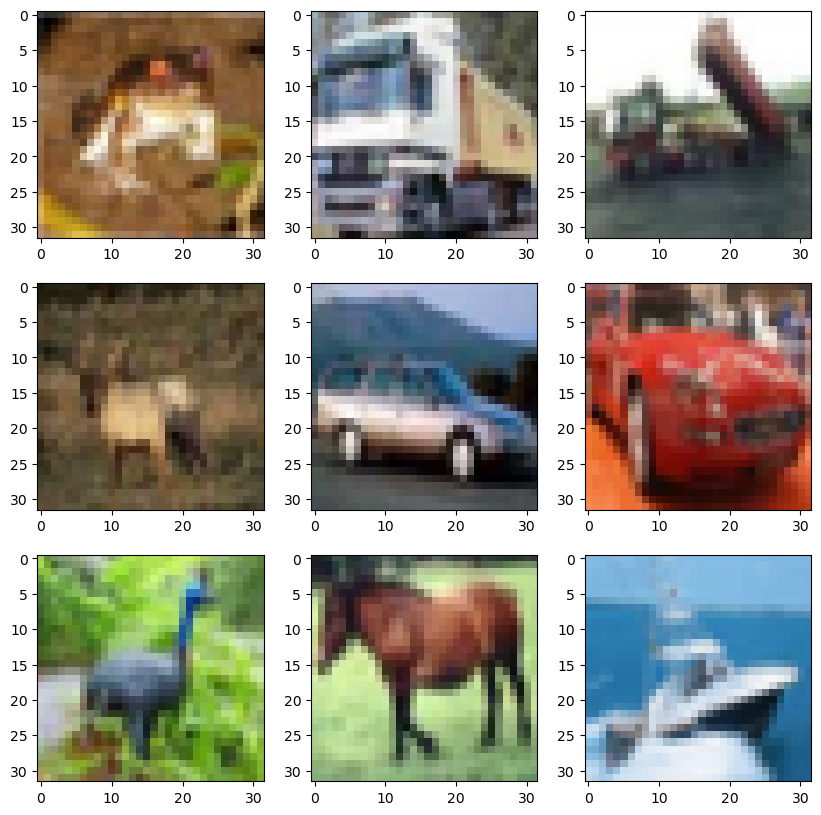

In [6]:
#IMG OF HAND WRITTEN DIGITS
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))
a = 0

for i in range(3):
    for j in range(3):
        axes[i,j].imshow(X_train_full[a], cmap=plt.get_cmap('grey'))
        a = a + 1
plt.show()

In [7]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dos', 'frog', 'horse', 'ship', 'truck']

In [8]:
class_names[y_train_full[8][0]]

'ship'

In [9]:
#NORMALIZE VALUES = when values are very different from eachother it cause unstabilization, it is harder for model
X_valid, X_train = X_train_full[:5000] / 255, X_train_full[5000:]/255 #internal test for every epoch, un seen examples
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test/255

In [10]:
X_train[0]

array([[[0.23529412, 0.32156863, 0.21176471],
        [0.15686275, 0.26666667, 0.14117647],
        [0.20392157, 0.31764706, 0.20392157],
        ...,
        [0.20784314, 0.16862745, 0.19607843],
        [0.25882353, 0.21568627, 0.23921569],
        [0.28627451, 0.24313725, 0.26666667]],

       [[0.43921569, 0.44705882, 0.44705882],
        [0.22745098, 0.27843137, 0.21960784],
        [0.22745098, 0.31764706, 0.20784314],
        ...,
        [0.21176471, 0.18431373, 0.20784314],
        [0.2627451 , 0.22745098, 0.25490196],
        [0.28235294, 0.24313725, 0.27058824]],

       [[0.66666667, 0.63137255, 0.69803922],
        [0.46666667, 0.4627451 , 0.47058824],
        [0.31372549, 0.34901961, 0.29019608],
        ...,
        [0.21960784, 0.19607843, 0.21960784],
        [0.2745098 , 0.24705882, 0.2745098 ],
        [0.28235294, 0.25098039, 0.27843137]],

       ...,

       [[0.35686275, 0.44313725, 0.36862745],
        [0.23137255, 0.3254902 , 0.24313725],
        [0.17647059, 0

In [11]:
##CREATE EXPONENTIAL SCHEDULING

In [12]:
def exponential_decay (epoch):
    return 0.01 * 0.01 ** (epoch / 10)

exponential_decay_fn = exponential_decay
lr_scheduler = keras.callbacks.LearningRateScheduler (exponential_decay_fn)

In [13]:
###  BUILD NEURAL NETWORK  ###

In [14]:
#CREATE MODEL AND ADD LAYERS TO IT

#chatgpt it
model = keras.models.Sequential([
    keras.layers.Flatten (input_shape = [32, 32, 3]),
    keras.layers.AlphaDropout (rate = 0.1),
    keras.layers.Dense (300, kernel_initializer = 'lecun_normal', activation = 'selu'),      #selu has the power to normalize the network automatically, 
    keras.layers.AlphaDropout (rate = 0.1),
    keras.layers.Dense (300, kernel_initializer = 'lecun_normal', activation = 'selu'),      #to use selu we need to normalize data first, we need a 
    keras.layers.AlphaDropout (rate = 0.1),
    keras.layers.Dense (300, kernel_initializer = 'lecun_normal', activation = 'selu'),      #fully connected nn, you need to use the lecun_normal init
    keras.layers.AlphaDropout (rate = 0.1),
    keras.layers.Dense (300, kernel_initializer = 'lecun_normal', activation = 'selu'),
    keras.layers.AlphaDropout (rate = 0.1),
    keras.layers.Dense (300, kernel_initializer = 'lecun_normal', activation = 'selu'),
    keras.layers.AlphaDropout (rate = 0.1),
    keras.layers.Dense (10, activation = 'softmax')
])

C:\Users\Sam\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
#FUNC THAT TELLS U HOW TOUR FUNCTIONS LOOKS LIKE
#PARAMETERS things that are going to be learned -> initialized 0 for biases and random for weights
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ alpha_dropout (AlphaDropout)         │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         921,900 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ alpha_dropout_1 (AlphaDropout)       │ (None, 300)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 300)                 │          90,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ alpha_dropout_2 (AlphaDropout)       │ (None, 300)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 300)                 │          90,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ alpha_dropout_3 (AlphaDropout)       │ (None, 300)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 300)                 │          90,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ alpha_dropout_4 (AlphaDropout)       │ (None, 300)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 300)                 │          90,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ alpha_dropout_5 (AlphaDropout)       │ (None, 300)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           3,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,286,110 (4.91 MB)

 Trainable params: 1,286,110 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.layers

[<Flatten name=flatten, built=True>,
 <AlphaDropout name=alpha_dropout, built=True>,
 <Dense name=dense, built=True>,
 <AlphaDropout name=alpha_dropout_1, built=True>,
 <Dense name=dense_1, built=True>,
 <AlphaDropout name=alpha_dropout_2, built=True>,
 <Dense name=dense_2, built=True>,
 <AlphaDropout name=alpha_dropout_3, built=True>,
 <Dense name=dense_3, built=True>,
 <AlphaDropout name=alpha_dropout_4, built=True>,
 <Dense name=dense_4, built=True>,
 <AlphaDropout name=alpha_dropout_5, built=True>,
 <Dense name=dense_5, built=True>]

In [17]:
#COMPILE MODEL

#GIVING HYPERPARAMETHERS = set yourslef, they cant be learnes -> hardcoded and not changed

#Loss measures how good the model is doing
#Metrics what you want your model to report on while learning
model.compile(loss='sparse_categorical_crossentropy', optimizer = 'sgd', metrics = ["accuracy"])      #SGD in keras uses the one with momentum


In [ ]:
#SET UP
#BATCH = batch size is a hyperparameter that defines the # of samples to work through before updating model, so we work in this case from 32 examples, fix it and then another 32 unitl you are done with all the training examples
#EPOCHS = how many times to do a pass over all the dataset
history = model.fit(X_train, y_train, epochs=60, validation_data = (X_valid, y_valid), batch_size=32, callbacks = [lr_scheduler])

Epoch 1/60
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.1814 - loss: 2.2772 - val_accuracy: 0.2618 - val_loss: 2.0469 - learning_rate: 0.0100
Epoch 2/60
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.2347 - loss: 2.0632 - val_accuracy: 0.2640 - val_loss: 2.0379 - learning_rate: 0.0063
Epoch 3/60
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.2548 - loss: 2.0140 - val_accuracy: 0.2774 - val_loss: 2.0123 - learning_rate: 0.0040
Epoch 4/60
  59/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.2572 - loss: 1.9927  

In [ ]:
# Model training loss is getting lower and validation loss gets higher, model is starting to overfit your training data -> DONT WANT THAT
# 1719 is number of batches

In [ ]:
#GRAPH

#as time goes, how loss and acciracy change and how validation loss and accuracy change
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca()
plt.show

In [ ]:
model.evaluate(X_test, y_test)

In [ ]:
#GET PREDICTION FOR TEST SET

In [ ]:
#Array show the probability to get each result
model.predict(X_test)

In [ ]:
#Showing the actual result and not the probability
y_prob = model.predict(X_test)
y_classes = y_prob.argmax(axis=-1)
y_classes

In [ ]:
#See which number was confused with which number the most
#Use tf confusion matrix funnction
confusion_matrix = tf.math.confusion_matrix(y_test, y_classes)

In [ ]:
#Plot confusion table
fig = sb.heatmap(confusion_matrix, annot=True, fmt='g', cmap= 'Greens') #annot=True to annotate cells

#Set titles and labels
fig.xaxis.set_ticklabels(class_names)
fig.yaxis.set_ticklabels(class_names)
fig.figure.set_size_inches(10, 10)

plt.show()